In [15]:
import numpy as np
import matplotlib.pyplot as plt

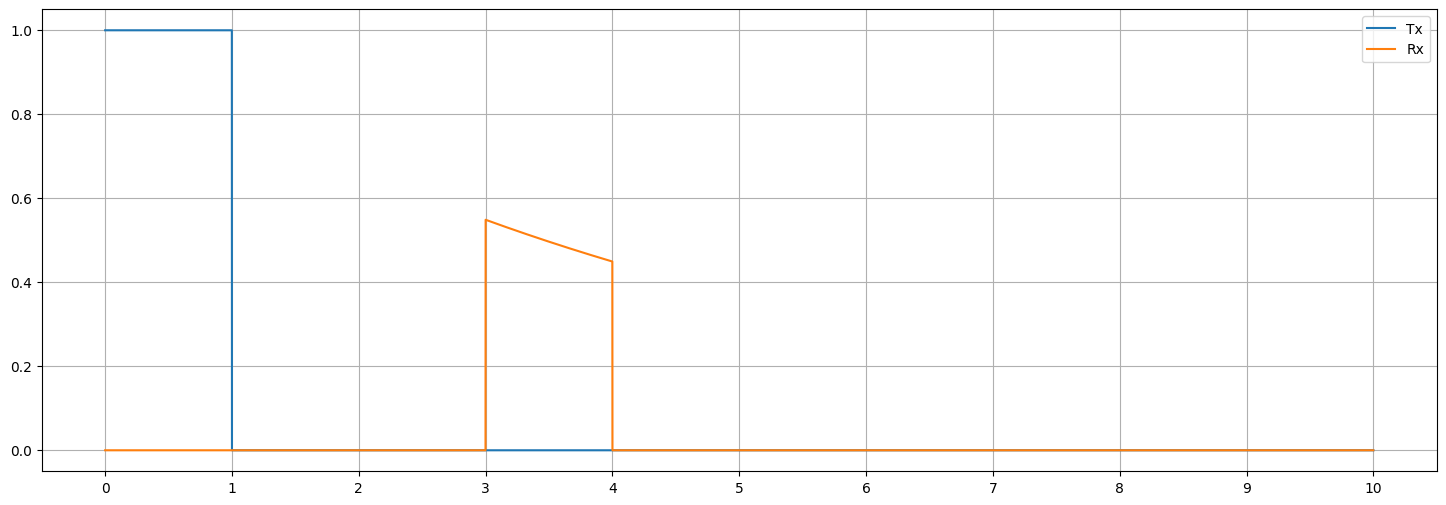

In [16]:
FS = 1000
T1 = 0
T2 = 10
t = np.linspace(T1, T2, (T2 - T1) * FS, endpoint=False)

pulse_start = 3
pulse_end = 4
tx = np.zeros(shape=t.shape)
rx = np.zeros(shape=t.shape)

tx[0: (pulse_end - pulse_start) * FS] = np.ones(shape=((pulse_end - pulse_start) * FS))
rx[pulse_start * FS: pulse_end * FS] = np.exp(-t[pulse_start * FS: pulse_end * FS] / 5)

plt.figure(figsize=(18, 6))
plt.grid()
plt.xticks(np.arange(0, 11, 1))
plt.plot(t, tx, label='Tx')
plt.plot(t, rx, label='Rx')
plt.legend()

Delay: -3.0s


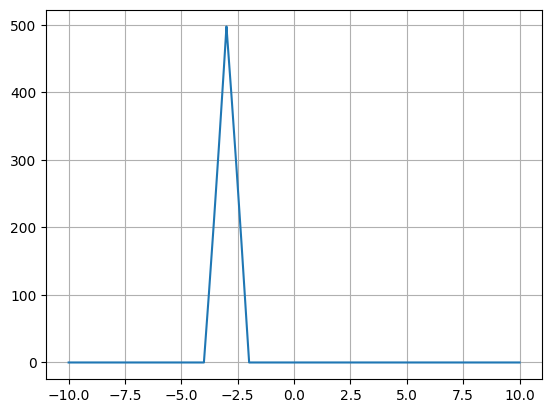

In [17]:
cross_corr = np.correlate(tx, rx, mode='full')
lags = np.arange(-len(tx)+1, len(rx))
lags_time = lags / FS
plt.grid()
plt.plot(lags_time, cross_corr)

idx = np.argmax(cross_corr)
print(f"Delay: {lags_time[idx]}s")